In [66]:
import os
import pandas as pd

base_dir = "/Users/sofiehultengren/Desktop/Kandidat_speciale/Pig_data_results/CT_result/Pig1_test "

rows = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        name, ext = os.path.splitext(file)
        
        # Kun table.tsv (ikke table.schema.tsv)
        if ext.lower() == ".tsv" and name.lower() == "table":
            file_path = os.path.join(root, file)

            df = pd.read_csv(file_path, sep="\t")

            row = df.iloc[0].copy()

            # 🔹 Brug mappenavnet som index i stedet
            folder_name = os.path.basename(root)
            row.name = folder_name

            rows.append(row)

final_df = pd.DataFrame(rows)

display(final_df)

,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,Surface mm2,Volume mm3 (CS),Volume cm3 (CS),Voxel count
Baseline_1_40%_LV,LV,225914.0,41966.0,41.9660,225914.0,41966.0,41.9660,32.0,285.0,168.792,26.7631,118.0,205.0,172.0,7834.74,41934.3,41.9343,NaN
INAP_1_35%_LV,LV,341683.0,63471.4,63.4714,341683.0,63471.4,63.4714,-199.0,1515.0,241.083,69.1870,141.0,315.0,244.0,10261.50,63434.3,63.4343,NaN
Release_1_40%_LV,LV,331411.0,61563.2,61.5632,331411.0,61563.2,61.5632,-730.0,3040.0,197.161,59.4545,132.0,235.0,199.0,9672.63,61527.1,61.5271,NaN
INAP_1_30%_LV,LV,NaN,63137.9,63.1379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9707.97,63102.6,63.1026,339888.0
Release_1_35%_LV,LV,346636.0,64391.4,64.3914,346636.0,64391.4,64.3914,-256.0,3345.0,189.674,52.7160,124.0,227.0,193.0,10112.90,64350.4,64.3504,NaN
INAP_1_40%_LV,LV,346332.0,64335.0,64.3350,346332.0,64335.0,64.3350,-119.0,2577.0,245.745,67.4337,154.0,313.0,252.0,10408.80,64286.1,64.2861,NaN
Baseline_1_35%_LV,LV,224253.0,41657.5,41.6575,224253.0,41657.5,41.6575,58.0,252.0,169.334,24.3353,122.0,202.0,172.0,7812.22,41626.6,41.6266,NaN
Baseline_1_30%_LV,LV,NaN,58799.7,58.7997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10259.50,58790.7,58.7907,316534.0
Release_1_30%_LV,LV,277381.0,51526.6,51.5266,277381.0,51526.6,51.5266,-627.0,1832.0,189.519,47.1396,128.0,228.0,192.0,8962.80,51485.7,51.4857,NaN
INAP_1_35%_LV_Bad,LV,307937.0,57202.7,57.2027,307937.0,57202.7,57.2027,-199.0,1341.0,247.951,64.6125,158.0,315.0,252.0,8924.31,57169.0,57.1690,NaN


In [67]:
df = final_df[["Volume cm3 (CS)"]]
df = df.rename(columns={"Volume cm3 (CS)": "Volume (mL)"})
df = df.sort_index()

In [68]:
display(df)

,Volume (mL)
Baseline_1_30%_LV,58.7907
Baseline_1_35%_LV,41.6266
Baseline_1_40%_LV,41.9343
Baseline_2_30%_LV,65.1034
Baseline_2_35%_LV,49.0255
Baseline_2_40%_LV,45.6590
INAP_1_30%_LV,63.1026
INAP_1_35%_LV,63.4343
INAP_1_35%_LV_Bad,57.1690
INAP_1_40%_LV,64.2861


AttributeError: module 'matplotlib.pyplot' has no attribute 'label'

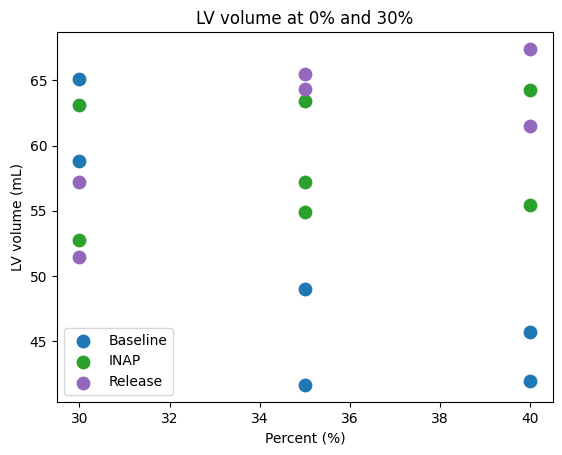

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

vol_col = "Volume (mL)"

plot_df = df.copy()
plot_df = plot_df.reset_index().rename(columns={"index": "name"})

def parse_name(s):
    s_low = s.lower()
    if "baseline" in s_low:
        cond = "Baseline"
    elif "inap" in s_low:
        cond = "INAP"
    elif "release" in s_low:
        cond = "Release"
    else:
        cond = "Other"
    m = re.search(r"_(\d+)%", s)
    pct = int(m.group(1)) if m else None
    return cond, pct

plot_df[["Condition", "Percent"]] = plot_df["name"].apply(
    lambda x: pd.Series(parse_name(x))
)

plot_df = plot_df.dropna(subset=["Percent"])

# Farver pr. condition
colors = {
    "Baseline": "tab:blue",
    "INAP": "tab:green",
    "Release": "tab:purple"
}

plt.figure()

for cond in plot_df["Condition"].unique():
    sub = plot_df[plot_df["Condition"] == cond]
    plt.scatter(
        sub["Percent"],
        sub[vol_col],
        label=cond,
        color=colors.get(cond, "gray"),
        s=80
    )

plt.xlabel("Percent (%)")
plt.ylabel("LV volume (mL)")
plt.title("LV volume at 0% and 30%")
plt.legend()

plt.tight_layout()
plt.show()


In [61]:
import os
import pandas as pd

base_dir = "/Users/sofiehultengren/Desktop/Kandidat_speciale/Pig_data_results/CT_result/Pig2_test"

rows = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        name, ext = os.path.splitext(file)
        
        # Kun table.tsv (ikke table.schema.tsv)
        if ext.lower() == ".tsv" and name.lower() == "table":
            file_path = os.path.join(root, file)

            df = pd.read_csv(file_path, sep="\t")

            row = df.iloc[0].copy()

            # 🔹 Brug mappenavnet som index i stedet
            folder_name = os.path.basename(root)
            row.name = folder_name

            rows.append(row)

final_df_2 = pd.DataFrame(rows)

display(final_df_2)

,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,Surface mm2,Volume mm3 (CS),Volume cm3 (CS)
Baseline_1_40%_LV,LV,262312,48727.3,48.7273,262312,48727.3,48.7273,-448,1735,167.074,46.6503,108,207,169,8540.57,48685.9,48.6859
INAP_1_35%_LV,LV,146873,27283.3,27.2833,146873,27283.3,27.2833,-126,1341,281.040,41.8423,226,321,282,5831.61,27250.9,27.2509
Release_1_40%_LV,LV,359401,66762.7,66.7627,359401,66762.7,66.7627,-730,3040,194.952,57.4732,121,235,199,9869.71,66721.8,66.7218
INAP_1_30%_LV,LV,158508,29444.6,29.4446,158508,29444.6,29.4446,-218,1822,275.292,50.2850,215,320,276,6428.33,29410.9,29.4109
Release_1_35%_LV,LV,303437,56366.8,56.3668,303437,56366.8,56.3668,-256,3345,194.875,50.9283,148,227,195,9072.89,56333.0,56.3330
INAP_1_40%_LV,LV,187251,34783.9,34.7839,187251,34783.9,34.7839,-5,1362,272.633,50.2154,204,316,275,6780.20,34750.9,34.7509
Baseline_1_35%_LV,LV,276795,51417.7,51.4177,276795,51417.7,51.4177,-61,2198,188.265,46.3766,129,223,192,8570.27,51385.0,51.3850
INAP_1_35%_LV_2 - Fejl men så er der 2,LV,185974,34546.7,34.5467,185974,34546.7,34.5467,-107,1341,275.121,52.3562,210,320,276,6569.74,34514.2,34.5142
Baseline_1_30%_LV,LV,296659,55107.7,55.1077,296659,55107.7,55.1077,-177,1117,169.520,40.1182,119,204,170,9256.61,55067.7,55.0677
Release_1_30%_LV,LV,274264,50947.6,50.9476,274264,50947.6,50.9476,-627,1832,193.824,43.9531,143,228,195,8616.71,50913.4,50.9134


In [62]:
df_2 = final_df_2[["Volume cm3 (CS)"]]
df_2 = df_2.rename(columns={"Volume cm3 (CS)": "Volume (mL)"})
df_2 = df_2.sort_index()

In [63]:
display(df_2) 

,Volume (mL)
Baseline_1_30%_LV,55.0677
Baseline_1_35%_LV,51.3850
Baseline_1_40%_LV,48.6859
Baseline_2_30%_LV,56.6949
Baseline_2_35%_LV,53.8658
Baseline_2_40%_LV,48.9261
INAP_1_30%_LV,29.4109
INAP_1_35%_LV,27.2509
INAP_1_35%_LV_2 - Fejl men så er der 2,34.5142
INAP_1_40%_LV,34.7509


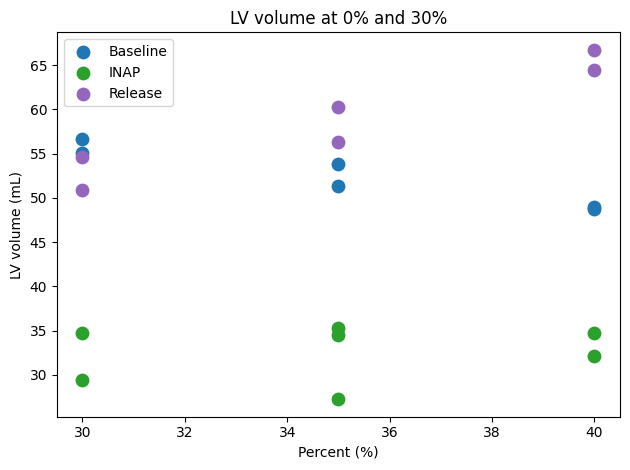

In [64]:
import re
import pandas as pd
import matplotlib.pyplot as plt

vol_col = "Volume (mL)"

plot_df = df_2.copy()
plot_df = plot_df.reset_index().rename(columns={"index": "name"})

def parse_name(s):
    s_low = s.lower()
    if "baseline" in s_low:
        cond = "Baseline"
    elif "inap" in s_low:
        cond = "INAP"
    elif "release" in s_low:
        cond = "Release"
    else:
        cond = "Other"
    m = re.search(r"_(\d+)%", s)
    pct = int(m.group(1)) if m else None
    return cond, pct

plot_df[["Condition", "Percent"]] = plot_df["name"].apply(
    lambda x: pd.Series(parse_name(x))
)

plot_df = plot_df.dropna(subset=["Percent"])

# Farver pr. condition
colors = {
    "Baseline": "tab:blue",
    "INAP": "tab:green",
    "Release": "tab:purple"
}

plt.figure()

for cond in plot_df["Condition"].unique():
    sub = plot_df[plot_df["Condition"] == cond]
    plt.scatter(
        sub["Percent"],
        sub[vol_col],
        label=cond,
        color=colors.get(cond, "gray"),
        s=80
    )

plt.xlabel("Percent (%)")
plt.ylabel("LV volume (mL)")
plt.title("LV volume at 0% and 30%")
plt.legend()
plt.tight_layout()
plt.show()


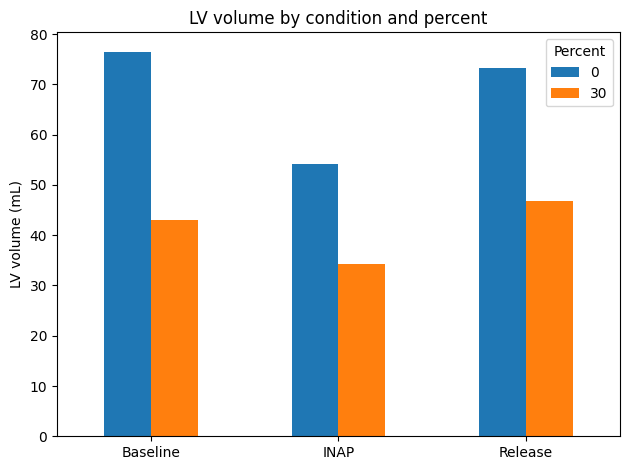

In [18]:
import matplotlib.pyplot as plt

pivot = plot_df.pivot_table(index="Condition", columns="Percent", values=vol_col, aggfunc="mean")
pivot = pivot.reindex(["Baseline", "INAP", "Release"])

ax = pivot.plot(kind="bar")
ax.set_xlabel("")
ax.set_ylabel("LV volume (mL)")
ax.set_title("LV volume by condition and percent")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


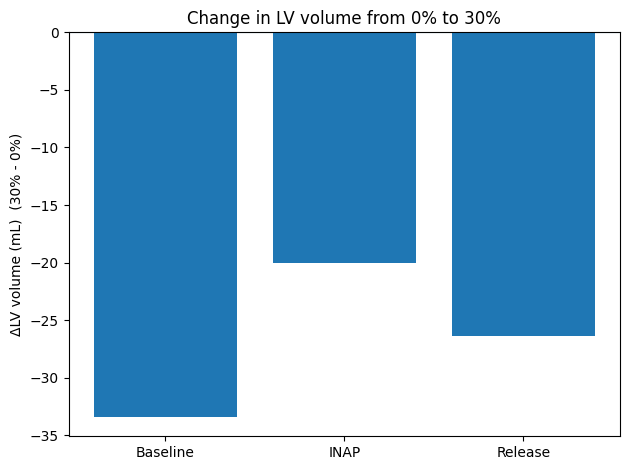

In [19]:
diff = pivot[30] - pivot[0]

plt.figure()
plt.bar(diff.index, diff.values)
plt.axhline(0)
plt.ylabel("ΔLV volume (mL)  (30% - 0%)")
plt.title("Change in LV volume from 0% to 30%")
plt.tight_layout()
plt.show()
